# Using K-Means Clustering  : standard library used

Extracting features from training images...
Saved features for 106.png to E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_train_feature\106.png_features.npy
Saved features for 107.png to E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_train_feature\107.png_features.npy
Saved features for 108.png to E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_train_feature\108.png_features.npy
Saved features for 109.png to E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_train_feature\109.png_features.npy
Saved features for 110.png to E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_train_feature\110.png_features.npy
Saved features for 111.png to E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_train_feature\111.p

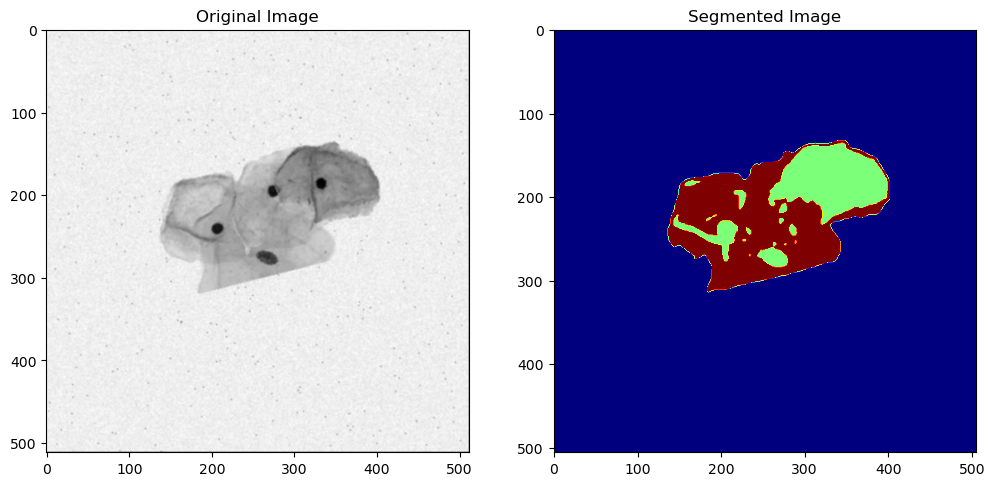

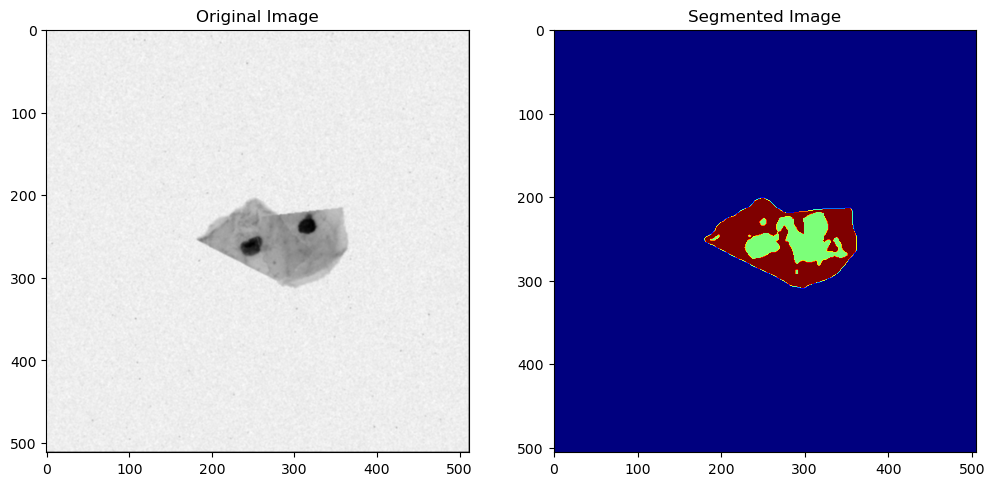

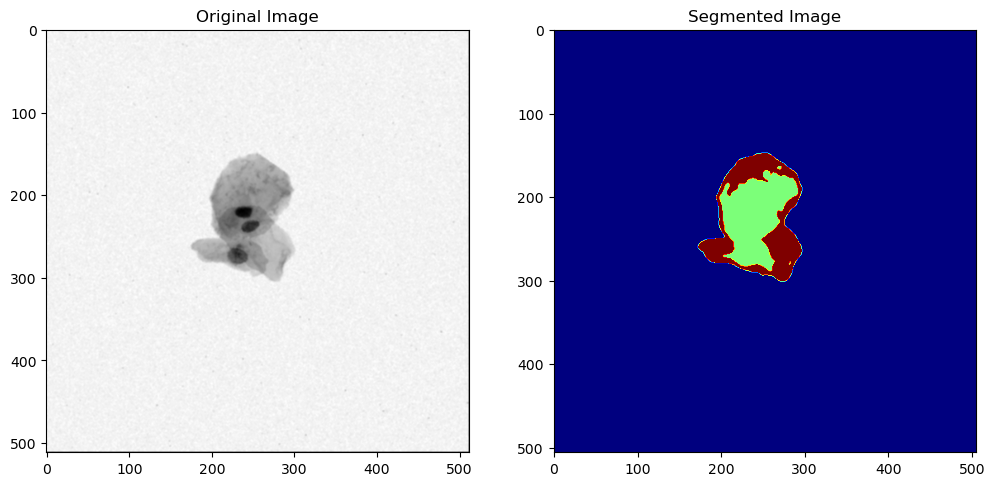

In [3]:
import os
import numpy as np
from skimage import io
from skimage.util import view_as_windows
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# Function to extract 7x7 patch features from the images
def extract_features(image, patch_size=(7, 7), shift=1):
    # Extract overlapping patches from the image
    patches = view_as_windows(image, patch_size, step=shift)
    # Reshape patches to (num_patches, patch_height, patch_width)
    patches = patches.reshape(-1, patch_size[0], patch_size[1])
    # Compute mean and std for each patch
    features = np.array([[np.mean(patch), np.std(patch)] for patch in patches])
    return features

# Function to process images in a folder and extract features
def process_image_dataset(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    for filename in os.listdir(input_folder):
        if filename.endswith(".png"):  # Assuming images are in PNG format
            image_path = os.path.join(input_folder, filename)
            image = io.imread(image_path, as_gray=True)  # Load image as grayscale
            features = extract_features(image)
            output_path = os.path.join(output_folder, f"{filename}_features.npy")
            np.save(output_path, features)
            print(f"Saved features for {filename} to {output_path}")

# Function to calculate the number of patches (grid) based on the image size
def calculate_patch_grid(image_shape, patch_size=(7, 7), shift=1):
    """ Calculate the number of patches along each dimension given the patch size and shift. """
    return (
        (image_shape[0] - patch_size[0]) // shift + 1,
        (image_shape[1] - patch_size[1]) // shift + 1
    )

# Function to display original and segmented images side by side
def display_segmentation_results(image, segmented_image):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(image, cmap='gray')
    ax[0].set_title('Original Image')
    ax[1].imshow(segmented_image, cmap='jet')
    ax[1].set_title('Segmented Image')
    plt.show()

# Function to train K-Means clustering on training dataset features
def train_kmeans_clustering(train_feature_folder, n_clusters=3):
    # Load all training features
    all_train_features = []
    for filename in os.listdir(train_feature_folder):
        if filename.endswith("_features.npy"):
            feature_path = os.path.join(train_feature_folder, filename)
            features = np.load(feature_path)
            all_train_features.append(features)
    
    all_train_features = np.vstack(all_train_features)  # Combine all training features into one array

    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    kmeans.fit(all_train_features)
    
    # Get the cluster centers (means) and assign each feature to a cluster
    cluster_centers = kmeans.cluster_centers_
    labels = kmeans.labels_
    
    # Calculate standard deviation for each cluster
    cluster_std_devs = []
    for i in range(n_clusters):
        cluster_features = all_train_features[labels == i]
        std_dev = np.std(cluster_features, axis=0)
        cluster_std_devs.append(std_dev)
    
    return cluster_centers, cluster_std_devs, kmeans

# Function to ensure the correct file extension
def ensure_png_extension(filename):
    if not filename.endswith(".png"):
        return f"{filename}.png"
    return filename

# Function to segment test images using the trained K-Means model
def segment_test_image_using_kmeans(test_feature_folder, kmeans_model, original_images_folder):
    for filename in os.listdir(test_feature_folder):
        if filename.endswith("_features.npy"):
            feature_path = os.path.join(test_feature_folder, filename)
            image_features = np.load(feature_path)
            
            # Predict the cluster labels for the test image features
            labels = kmeans_model.predict(image_features)
            
            # Load the original image to determine its shape
            original_image_filename = filename.replace('_features.npy', '')
            original_image_filename = ensure_png_extension(original_image_filename)  # Ensure correct extension
            original_image_path = os.path.join(original_images_folder, original_image_filename)
            
            if not os.path.exists(original_image_path):
                print(f"File not found: {original_image_path}")
                continue
            
            original_image = io.imread(original_image_path, as_gray=True)
            image_shape = original_image.shape
            
            # Reshape the labels to match the patch grid shape of the original image
            patch_grid_shape = calculate_patch_grid(image_shape)
            segmented_image = labels.reshape(patch_grid_shape)
            
            # Display results
            display_segmentation_results(original_image, segmented_image)


# Set the paths for the training and test datasets
train_images_folder = r'E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\Train'  # Set your path
test_images_folder = r'E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\Test'    # Set your path
train_output_folder = r'E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_train_feature'
test_output_folder = r'E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_test_feature'

# Step 1: Extract features from training and test images
print("Extracting features from training images...")
process_image_dataset(train_images_folder, train_output_folder)

print("Extracting features from test images...")
process_image_dataset(test_images_folder, test_output_folder)

# Step 2: Perform K-Means clustering on training image features
print("Training K-Means clustering model on training features...")
cluster_means, cluster_std_devs, kmeans_model = train_kmeans_clustering(train_output_folder)

# Step 3: Print the final cluster parameters
for i, (mean, std_dev) in enumerate(zip(cluster_means, cluster_std_devs)):
    print(f"Cluster {i+1}:\nMean: {mean}\nStandard Deviation: {std_dev}\n")

# Step 4: Perform segmentation on test images using the trained K-Means model
print("Segmenting test images using the trained K-Means model...")
segment_test_image_using_kmeans(test_output_folder, kmeans_model, test_images_folder)


# Using Modified K-Means Clustering : standard library used

Training K-Means clustering model on training features...
Segmenting test images using the modified K-Means (Mahalanobis distance) model...


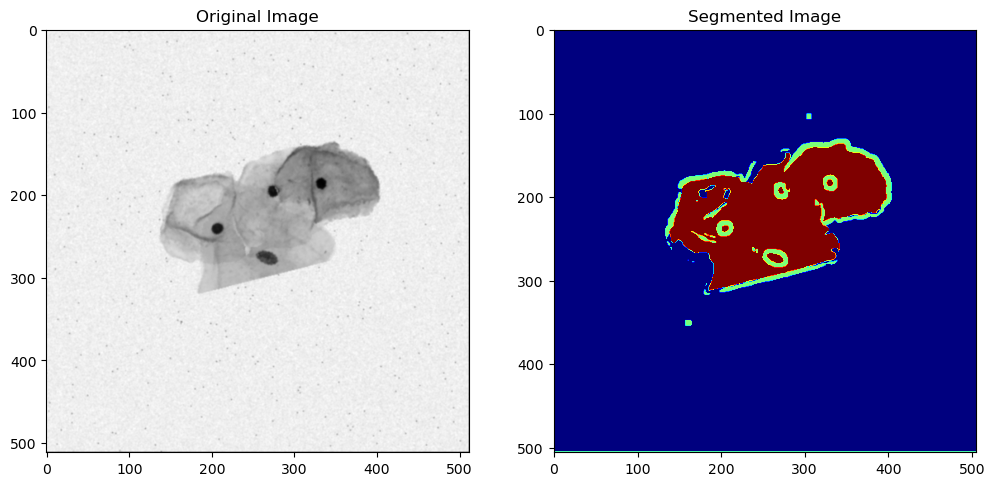

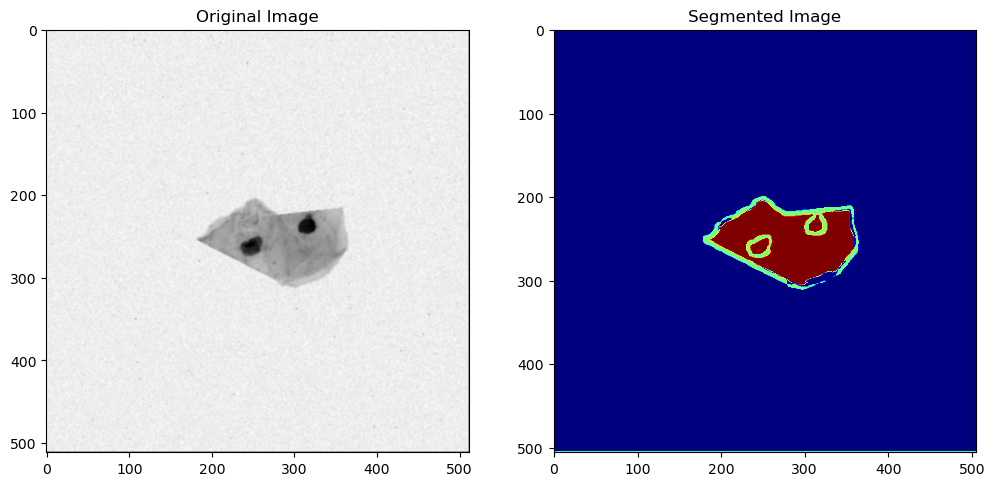

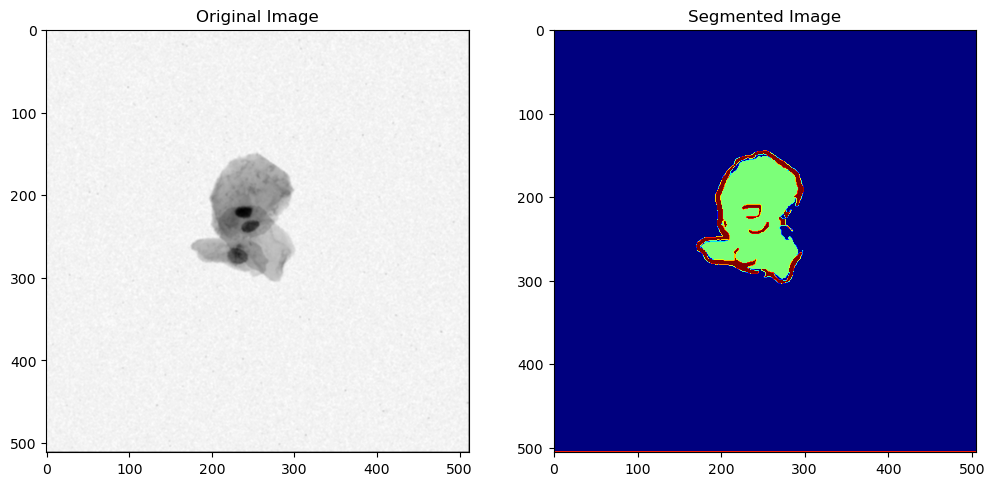

In [11]:
import os
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from skimage import io


# Function to calculate Mahalanobis distance between points and cluster centers
def mahalanobis_distance(features, cluster_centers):
    # Compute the covariance matrix of the features and its inverse
    covariance_matrix = np.cov(features.T)
    inv_cov_matrix = np.linalg.inv(covariance_matrix)
    
    # Compute Mahalanobis distance between each feature and each cluster center
    distances = pairwise_distances(features, cluster_centers, metric='mahalanobis', VI=inv_cov_matrix)
    return distances

# Modified K-Means using Mahalanobis distance
def modified_kmeans_mahalanobis(features, initial_cluster_centers, n_clusters=3, max_iters=100, tol=1e-4):
    cluster_centers = initial_cluster_centers  # Start with the same initial centers
    for iteration in range(max_iters):
        # Step 1: Compute Mahalanobis distance between features and cluster centers
        distances = mahalanobis_distance(features, cluster_centers)
        
        # Step 2: Assign each point to the nearest cluster center
        labels = np.argmin(distances, axis=1)
        
        # Step 3: Recompute cluster centers based on current assignments
        new_cluster_centers = np.array([features[labels == i].mean(axis=0) for i in range(n_clusters)])
        
        # Step 4: Check for convergence (if the cluster centers don't change much)
        if np.linalg.norm(new_cluster_centers - cluster_centers) < tol:
            break
        
        # Update cluster centers
        cluster_centers = new_cluster_centers
    
    return labels, cluster_centers

# Function to calculate the number of patches (grid) based on the image size
def calculate_patch_grid(image_shape, patch_size=(7, 7), shift=1):
    return (
        (image_shape[0] - patch_size[0]) // shift + 1,
        (image_shape[1] - patch_size[1]) // shift + 1
    )

# Function to display original and segmented images side by side
def display_segmentation_results(image, segmented_image):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(image, cmap='gray')
    ax[0].set_title('Original Image')
    ax[1].imshow(segmented_image, cmap='jet')
    ax[1].set_title('Segmented Image')
    plt.show()

# Function to ensure the correct file extension
def ensure_png_extension(filename):
    if not filename.endswith(".png"):
        return f"{filename}.png"
    return filename

# Function to perform segmentation on test images using the trained Mahalanobis-based K-Means model
def segment_test_image_using_modified_kmeans(test_feature_folder, cluster_centers, original_images_folder, patch_size=(7, 7), shift=1):
    for filename in os.listdir(test_feature_folder):
        if filename.endswith("_features.npy"):
            feature_path = os.path.join(test_feature_folder, filename)
            image_features = np.load(feature_path)
            
            # Perform Mahalanobis-based K-Means clustering on test image features
            labels, _ = modified_kmeans_mahalanobis(image_features, cluster_centers)
            
            # Load the original image to determine its shape
            original_image_filename = filename.replace('_features.npy', '')
            original_image_filename = ensure_png_extension(original_image_filename)
            original_image_path = os.path.join(original_images_folder, original_image_filename)
            
            if not os.path.exists(original_image_path):
                print(f"File not found: {original_image_path}")
                continue
            
            original_image = io.imread(original_image_path, as_gray=True)
            image_shape = original_image.shape
            
            # Reshape the labels to match the patch grid shape of the original image
            patch_grid_shape = calculate_patch_grid(image_shape, patch_size, shift)
            segmented_image = labels.reshape(patch_grid_shape)
            
            # Display results
            display_segmentation_results(original_image, segmented_image)


# Function to train K-Means clustering and obtain initial cluster centers
def train_kmeans_clustering(train_feature_folder, n_clusters=3):
    # Load all training features
    all_train_features = []
    for filename in os.listdir(train_feature_folder):
        if filename.endswith("_features.npy"):
            feature_path = os.path.join(train_feature_folder, filename)
            features = np.load(feature_path)
            all_train_features.append(features)
    
    all_train_features = np.vstack(all_train_features)  # Combine all training features into one array

    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    kmeans.fit(all_train_features)
    
    # Get the cluster centers (means) and assign each feature to a cluster
    cluster_centers = kmeans.cluster_centers_
    
    return cluster_centers, kmeans

# Set the paths for the training and test datasets
train_output_folder = r'E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_train_feature'  # Path where train features are stored
test_output_folder = r'E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_test_feature'    # Path where test features are stored
test_images_folder = r'E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\Test'     # Path to the original test images

# Step 1: Perform standard K-Means clustering to get initial centers
print("Training K-Means clustering model on training features...")
initial_cluster_centers, kmeans_model = train_kmeans_clustering(train_output_folder)

# Step 2: Perform segmentation on test images using modified K-Means with Mahalanobis distance
print("Segmenting test images using the modified K-Means (Mahalanobis distance) model...")
segment_test_image_using_modified_kmeans(test_output_folder, initial_cluster_centers, test_images_folder)


# Using K-Means Clustering  : without standard library

Segmenting test images using manual K-Means clustering (Euclidean distance)...


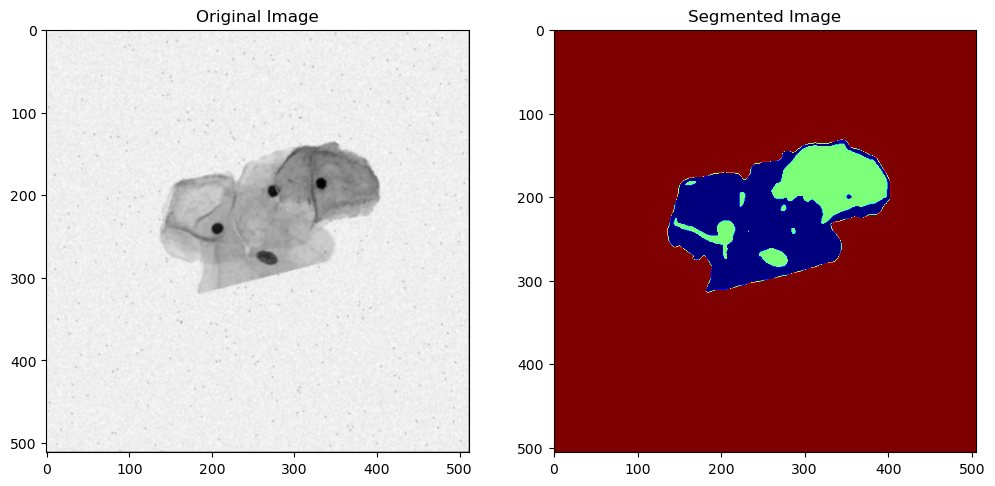

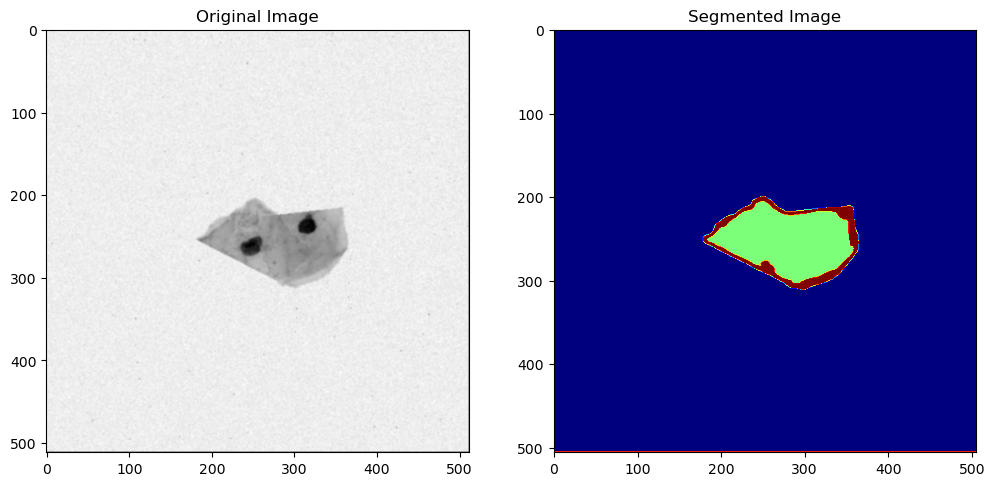

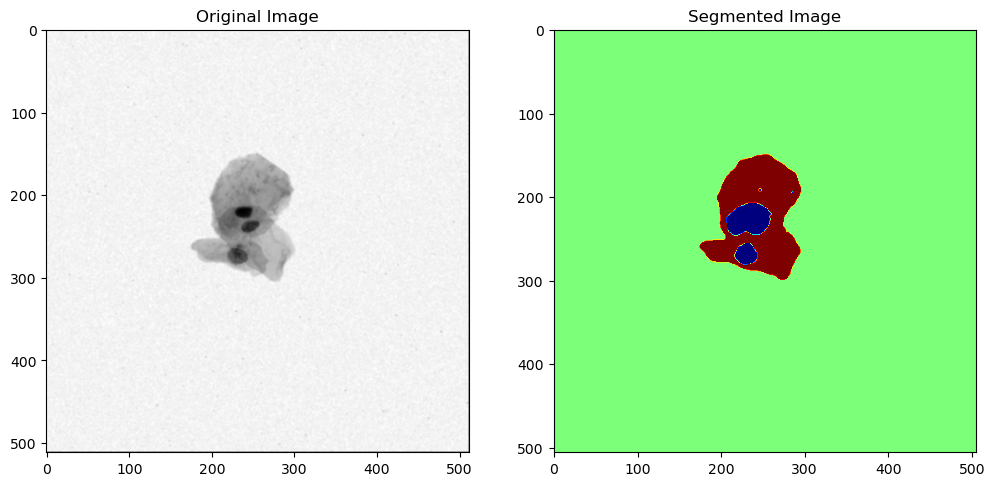

In [18]:
import os
import numpy as np
from skimage import io
import matplotlib.pyplot as plt


# Function to initialize K-Means clusters (randomly selects initial centers)
def initialize_clusters(features, n_clusters):
    indices = np.random.choice(features.shape[0], n_clusters, replace=False)
    return features[indices]

# Function to assign points to the nearest cluster (Euclidean distance)
def assign_clusters(features, cluster_centers):
    distances = np.linalg.norm(features[:, np.newaxis] - cluster_centers, axis=2)
    labels = np.argmin(distances, axis=1)
    return labels

# Function to update cluster centers
def update_clusters(features, labels, n_clusters):
    new_centers = np.array([features[labels == i].mean(axis=0) for i in range(n_clusters)])
    return new_centers

# Manual K-Means clustering algorithm
def kmeans_clustering(features, n_clusters=3, max_iters=100, tol=1e-4):
    # Step 1: Initialize cluster centers
    cluster_centers = initialize_clusters(features, n_clusters)
    
    for iteration in range(max_iters):
        # Step 2: Assign each point to the nearest cluster center
        labels = assign_clusters(features, cluster_centers)
        
        # Step 3: Update cluster centers
        new_cluster_centers = update_clusters(features, labels, n_clusters)
        
        # Step 4: Check for convergence
        if np.linalg.norm(new_cluster_centers - cluster_centers) < tol:
            break
        
        cluster_centers = new_cluster_centers
    
    return labels, cluster_centers

# Function to calculate the number of patches (grid) based on the image size
def calculate_patch_grid(image_shape, patch_size=(7, 7), shift=1):
    return (
        (image_shape[0] - patch_size[0]) // shift + 1,
        (image_shape[1] - patch_size[1]) // shift + 1
    )

# Function to display original and segmented images side by side
def display_segmentation_results(image, segmented_image):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(image, cmap='gray')
    ax[0].set_title('Original Image')
    ax[1].imshow(segmented_image, cmap='jet')
    ax[1].set_title('Segmented Image')
    plt.show()

# Function to ensure the correct file extension
def ensure_png_extension(filename):
    if not filename.endswith(".png"):
        return f"{filename}.png"
    return filename

# Function to segment test images using the manually implemented K-Means clustering
def segment_test_image_using_manual_kmeans(test_feature_folder, cluster_centers, original_images_folder, patch_size=(7, 7), shift=1):
    for filename in os.listdir(test_feature_folder):
        if filename.endswith("_features.npy"):
            feature_path = os.path.join(test_feature_folder, filename)
            image_features = np.load(feature_path)
            
            # Perform K-Means clustering on test image features
            labels, _ = kmeans_clustering(image_features, n_clusters=len(cluster_centers), max_iters=100)
            
            # Load the original image to determine its shape
            original_image_filename = filename.replace('_features.npy', '')
            original_image_filename = ensure_png_extension(original_image_filename)
            original_image_path = os.path.join(original_images_folder, original_image_filename)
            
            if not os.path.exists(original_image_path):
                print(f"File not found: {original_image_path}")
                continue
            
            original_image = io.imread(original_image_path, as_gray=True)
            image_shape = original_image.shape
            
            # Reshape the labels to match the patch grid shape of the original image
            patch_grid_shape = calculate_patch_grid(image_shape, patch_size, shift)
            segmented_image = labels.reshape(patch_grid_shape)
            
            # Display results
            display_segmentation_results(original_image, segmented_image)


# Set the paths for the test dataset and original images
test_output_folder = r'E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_test_feature'    # Path where test features are stored
test_images_folder = r'E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\Test'     # Path to the original test images

# Initialize cluster centers from the training dataset (you can replace this with actual values)
initial_cluster_centers = np.random.rand(3, 2)  # Dummy example centers, replace with actual ones

# Step 1: Perform segmentation on test images using manually implemented K-Means clustering
print("Segmenting test images using manual K-Means clustering (Euclidean distance)...")
segment_test_image_using_manual_kmeans(test_output_folder, initial_cluster_centers, test_images_folder)


# Using Modified K-Means Clustering  : without standard library

Segmenting test images using modified K-Means clustering (Mahalanobis distance)...


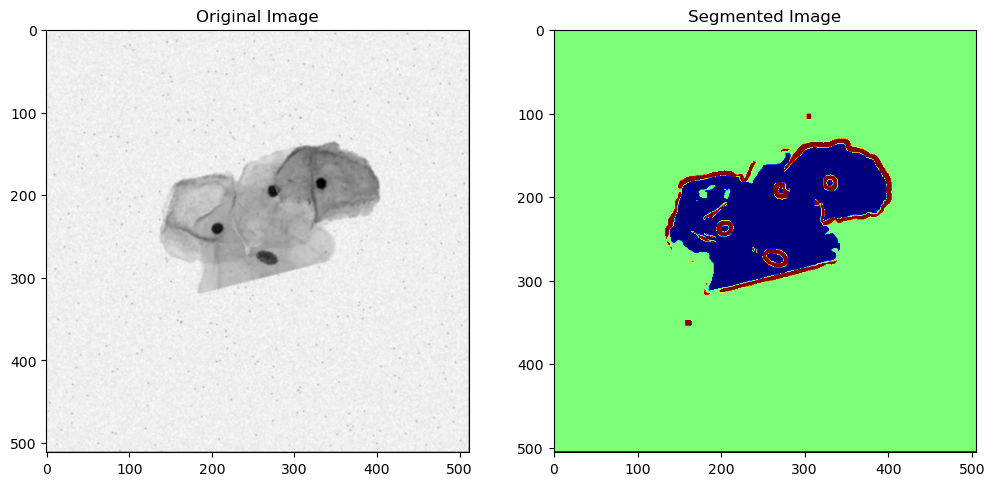

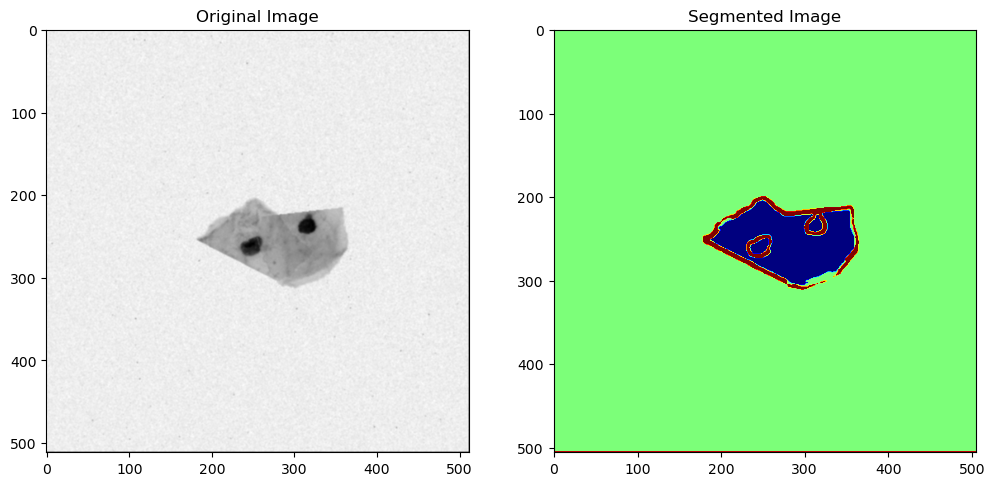

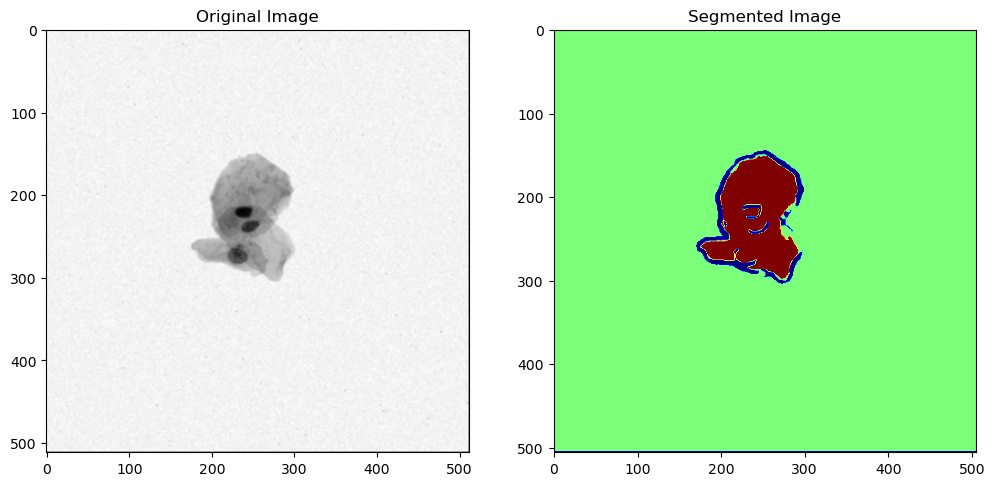

In [33]:
import os
import numpy as np
from sklearn.metrics import pairwise_distances
from skimage import io
import matplotlib.pyplot as plt

# Function to calculate Mahalanobis distance between points and cluster centers
def mahalanobis_distance(features, cluster_centers):
    # Compute the covariance matrix of the features and its inverse
    covariance_matrix = np.cov(features.T)
    inv_cov_matrix = np.linalg.inv(covariance_matrix)
    
    # Compute Mahalanobis distance between each feature and each cluster center
    distances = pairwise_distances(features, cluster_centers, metric='mahalanobis', VI=inv_cov_matrix)
    return distances

# Manual Modified K-Means using Mahalanobis distance with handling of empty clusters
def modified_kmeans_mahalanobis(features, initial_cluster_centers, n_clusters=3, max_iters=100, tol=1e-4):
    cluster_centers = initial_cluster_centers  # Start with the same initial centers
    
    for iteration in range(max_iters):
        # Step 1: Compute Mahalanobis distance between features and cluster centers
        distances = mahalanobis_distance(features, cluster_centers)
        
        # Step 2: Assign each point to the nearest cluster center
        labels = np.argmin(distances, axis=1)
        
        # Step 3: Recompute cluster centers based on current assignments
        new_cluster_centers = []
        for i in range(n_clusters):
            cluster_points = features[labels == i]
            if len(cluster_points) > 0:
                new_center = cluster_points.mean(axis=0)
            else:
                # Handle empty cluster by reinitializing the center to a random point
                new_center = features[np.random.choice(features.shape[0])]
            new_cluster_centers.append(new_center)
        new_cluster_centers = np.array(new_cluster_centers)
        
        # Step 4: Check for convergence
        if np.linalg.norm(new_cluster_centers - cluster_centers) < tol:
            break
        
        cluster_centers = new_cluster_centers
    
    return labels, cluster_centers

# Function to calculate the number of patches (grid) based on the image size
def calculate_patch_grid(image_shape, patch_size=(7, 7), shift=1):
    return (
        (image_shape[0] - patch_size[0]) // shift + 1,
        (image_shape[1] - patch_size[1]) // shift + 1
    )

# Function to display original and segmented images side by side
def display_segmentation_results(image, segmented_image):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(image, cmap='gray')
    ax[0].set_title('Original Image')
    ax[1].imshow(segmented_image, cmap='jet')
    ax[1].set_title('Segmented Image')
    plt.show()

# Function to ensure the correct file extension
def ensure_png_extension(filename):
    if not filename.endswith(".png"):
        return f"{filename}.png"
    return filename

# Function to segment test images using the manually implemented Modified K-Means clustering (Mahalanobis)
def segment_test_image_using_modified_kmeans(test_feature_folder, cluster_centers, original_images_folder, patch_size=(7, 7), shift=1):
    for filename in os.listdir(test_feature_folder):
        if filename.endswith("_features.npy"):
            feature_path = os.path.join(test_feature_folder, filename)
            image_features = np.load(feature_path)
            
            # Perform Mahalanobis-based K-Means clustering on test image features
            labels, _ = modified_kmeans_mahalanobis(image_features, cluster_centers, n_clusters=len(cluster_centers), max_iters=100)
            
            # Load the original image to determine its shape
            original_image_filename = filename.replace('_features.npy', '')
            original_image_filename = ensure_png_extension(original_image_filename)
            original_image_path = os.path.join(original_images_folder, original_image_filename)
            
            if not os.path.exists(original_image_path):
                print(f"File not found: {original_image_path}")
                continue
            
            original_image = io.imread(original_image_path, as_gray=True)
            image_shape = original_image.shape
            
            # Reshape the labels to match the patch grid shape of the original image
            patch_grid_shape = calculate_patch_grid(image_shape, patch_size, shift)
            segmented_image = labels.reshape(patch_grid_shape)
            
            # Display results
            display_segmentation_results(original_image, segmented_image)


# Set the paths for the test dataset and original images
test_output_folder = r'E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\output_test_feature'    # Path where test features are stored
test_images_folder = r'E:\iit dh\Assignmet_IIT_DH\SPR_assignment\Assgiment2\cervical_cytology_cell_Image_dataset\Test'     # Path to the original test images

# Initialize cluster centers from the training dataset (you can replace this with actual values)
initial_cluster_centers = np.random.rand(3, 2)  # Dummy example centers, replace with actual ones

# Step 1: Perform segmentation on test images using manually implemented Modified K-Means clustering (Mahalanobis distance)
print("Segmenting test images using modified K-Means clustering (Mahalanobis distance)...")
segment_test_image_using_modified_kmeans(test_output_folder, initial_cluster_centers, test_images_folder)
